# Introducción a Tensorflow 2


In [1]:
import time
import numpy as np
import pandas as pd
import tensorflow as tf
from matplotlib import pyplot as plt
from sklearn.metrics import (
    accuracy_score,
    recall_score,
    f1_score,
    roc_auc_score,
    precision_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
)
print(tf.__version__)

2.21.0


## Conjunto de datos
Para comenzar, utilizaremos un clásico conjunto de datos denominado [MNIST](http://yann.lecun.com/exdb/mnist/), formado por un conjunto de imágenes de dígitos manuscritos
![images](https://storage.googleapis.com/tfds-data/visualization/fig/mnist-3.0.1.png)

In [2]:
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.mnist.load_data()

El conjunto de entrenamiento está formado por 60.000 imágenes de 28x28, mientras que el de test lo forman 10.000 imágenes. El problema de clasificación consiste en distinguir entre los 10 dígitos diferentes

In [3]:
print("Datos de entrenamiento", x_train.shape)
print("Datos de test", x_test.shape)
print("Primeros dígitos: ", y_train[:5])

Datos de entrenamiento (60000, 28, 28)
Datos de test (10000, 28, 28)
Primeros dígitos:  [5 0 4 1 9]


## Pre-procesamiento
Como suele ser habitual, es conveniente realizar algún tipo de procesamiento antes de que los datos sean tratados por el modelo. En este caso, haremos un pequeño procesamiento que consiste en escalar los valores entre 0 y 1. Para ello, bastará con dividir por 255, ya que cada pixel de las imágenes de entrada viene representado por un entero entre 0 y 255 (8 bits) indicando su tonalidad de gris.

In [4]:
x_train = x_train / 255.0
x_test = x_test / 255.0
x_train.dtype

dtype('float64')

## Modelo
Para crear un modelo, primero tenemos que definir la arquitectura neuronal. El caso más sencillo es definir una estructura secuencial de capas, donde la primera actúa de capa de entrada y la última de salida del modelo. Cada capa tendrá una serie de parámetros dependiendo del tipo, habitualmente habrá que especificar el tamaño (número de neuronas), función de activación, etc.

In [5]:
model = tf.keras.models.Sequential([
  tf.keras.layers.Flatten(input_shape=(28,28)),
  tf.keras.layers.Dense(128, activation='relu'),
  tf.keras.layers.Dense(10, activation='softmax')
])

D:\Dev\Universidad\uma-26-27-1\.venv\Lib\site-packages\keras\src\layers\reshaping\flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


## Entrenamiento
Antes de entrenar, hay que compilar el modelo indicando:
- La **regla de aprendizaje** (*optimizer*) que define el algoritmo para actualizar los pesos sinápticos de la red
- La **función objetivo** o de pérdida (*loss*), que es optimizada por la regla de aprendizaje
- La **métrica** o medida de evaluación (*metrics*) utilizada para evaluar el modelo entrenado

In [6]:
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

Tras compilar el modelo, el entrenamiento se define mediante los siguientes parámetros:
- **Épocas** (*epochs*). Número de veces que se le muestra el conjunto de entrenamiento al modelo
- Tamaño de **lote** (*batch_size*). Número de instancias o patrones que se muestran al modelo para actualizar los pesos sinápticos
- Conjunto de **validación** (*validation_spli*). Datos utilizados para medir el rendimiento durante el entrenamiento

En este caso, se ha optado por los valores por defecto

In [7]:
h=model.fit(x_train, y_train, epochs=5)

Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 1ms/step - accuracy: 0.9269 - loss: 0.2564
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - accuracy: 0.9671 - loss: 0.1110
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - accuracy: 0.9764 - loss: 0.0776
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - accuracy: 0.9817 - loss: 0.0588
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9861 - loss: 0.0460


## Evaluación
Una vez entrenada la red neuronal, prodremos obtener las medidas de rendimiento espcificadas en la etapa anterior, tanto para el conjunto de entrenamiento como para el conjunto de test

In [8]:
model.evaluate(x_train, y_train)
model.evaluate(x_test, y_test)

1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 977us/step - accuracy: 0.9915 - loss: 0.0307
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 928us/step - accuracy: 0.9780 - loss: 0.0729 


[0.07291440665721893, 0.9779999852180481]

---

## Funciones auxiliares

He encapsulado todo el proceso en dos funciones para evitar la duplicación de código en los experimentos y garantizar que todos los experimentos se evalúen bajo las mismas condiciones a partir de una semilla definida. Tenemos las dos siguientes funciones:

- `entrenar_evaluar()`: Se encarga de entrenar y evaluar un modelo pasando como parámetros el optimizador, learning rate, batch size, número de épocas y conjunto de datos. Al final obtenemos un diccionario con métricas útiles de clasificación, matrices de confusión, historial de entrenamiento, el modelo entrenado y los datos predichos.
- `resumen()`: Muestra por pantalla de forma gráfica las matrices de confusión y las curvas de error y accuracy.

In [9]:
def entrenar_evaluar(opt, lr, batch_size, epochs, x_tr, y_tr, x_te, y_te):
    tf.keras.utils.set_random_seed(42)

    match opt.lower(): # elegimos el optimizador de uno de los siguientes
        case "adam": optimizer = tf.keras.optimizers.Adam(learning_rate=lr)
        case "rmsprop": optimizer = tf.keras.optimizers.RMSprop(learning_rate=lr)
        case "sgd": optimizer = tf.keras.optimizers.SGD(learning_rate=lr)
        case "sgd_momentum": optimizer = tf.keras.optimizers.SGD(learning_rate=lr, momentum=0.9)
        case _: raise ValueError("Optimizador incorrecto")

    model1 = tf.keras.models.Sequential([ # creamos la red
        tf.keras.layers.Flatten(input_shape=(28,28)),
        tf.keras.layers.Dense(128, activation="relu"),
        tf.keras.layers.Dense(10, activation="softmax")
    ])

    model1.compile(
        optimizer=optimizer,
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )

    t_ini = time.time() # calculamos el tiempo exacto del entrenamiento
    h = model1.fit(x_tr, y_tr, epochs=epochs, batch_size=batch_size)
    t_total = time.time() - t_ini

    prob_tr = model1.predict(x_tr, batch_size=batch_size) # obtenemos las salidas del modelo (lista de probabilidades)
    prob_te = model1.predict(x_te, batch_size=batch_size)
    pred_tr = np.argmax(prob_tr, axis=1) # la predicccion es la salida con mayor probabilidad
    pred_te = np.argmax(prob_te, axis=1)

    acc_tr = accuracy_score(y_tr, pred_tr) # calculamos el accuracy
    acc_te = accuracy_score(y_te, pred_te)

    num_err_tr = int(sum(pred_tr != y_tr)) # numero de errores
    num_err_te = int(sum(pred_te != y_te))

    prec_te = precision_score(y_te, pred_te, average="macro")
    rec_te = recall_score(y_te, pred_te, average="macro")
    f1_te = f1_score(y_te, pred_te, average="macro")
    auc_te = roc_auc_score(y_te, prob_te, multi_class="ovr")

    cm_tr = confusion_matrix(y_tr, pred_tr) # creamos las matrices de confusion
    cm_te = confusion_matrix(y_te, pred_te)

    metricas = {
        "optimizador": opt,
        "learning_rate": lr,
        "batch_size": batch_size,
        "epochs": epochs,
        "tiempo_entrenamiento(s)": round(t_total, 2),
        "train_accuracy": round(acc_tr, 4),
        "test_accuracy": round(acc_te, 4),
        "errores_train": f"{num_err_tr}/{len(y_tr)}",
        "errores_test": f"{num_err_te}/{len(y_te)}",
        "precision": round(prec_te, 4),
        "recall": round(rec_te, 4),
        "f1_score": round(f1_te, 4),
        "auc_roc": round(auc_te, 4),
    }

    return metricas, model1, cm_tr, cm_te, pred_te, h

def resumen(cm_tr, cm_te, h):
    fig, axes = plt.subplots(1, 3, figsize=(12, 4))

    axes[0].set_title("train confusion matrix")
    cmd = ConfusionMatrixDisplay(cm_tr)
    cmd.plot(ax=axes[0])

    axes[1].set_title("test confusion matrix")
    cmd = ConfusionMatrixDisplay(cm_te)
    cmd.plot(ax=axes[1])

    axes[2].plot(h.history["loss"], label="loss", color="b")
    axes[2].plot(h.history["accuracy"], label="accuracy", color="g")
    axes[2].set_xlabel("epochs")
    axes[2].set_ylim(0, 1)
    axes[2].legend()
    axes[2].grid(True)

    plt.tight_layout()
    plt.show()

In [10]:
metricas = pd.DataFrame()

## Bloque 1 - Optimizadores
### Experimento 0

Para empezar usamos la configuración base del ejercicio: el optimizador Adam con un learning rate de 0.001, lotes de 32 imágenes y 5 épocas. El objetivo es fijar un punto de partida para ver cómo influye cada cambio después. Elegimos Adam porque adapta el ritmo de aprendizaje a cada peso de forma automática, y con un lote pequeño de 32 obligamos a la red a recalcular y corregir sus pesos más veces por época

Epoch 1/5


D:\Dev\Universidad\uma-26-27-1\.venv\Lib\site-packages\keras\src\layers\reshaping\flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - accuracy: 0.9276 - loss: 0.2530
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9670 - loss: 0.1112
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - accuracy: 0.9775 - loss: 0.0754
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - accuracy: 0.9836 - loss: 0.0547
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - accuracy: 0.9880 - loss: 0.0403
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 1s 679us/step
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 772us/step


,optimizador,learning_rate,batch_size,epochs,tiempo_entrenamiento(s),train_accuracy,test_accuracy,errores_train,errores_test,precision,recall,f1_score,auc_roc
0,adam,0.001,32,5,14.46,0.9892,0.9758,649/60000,242/10000,0.9759,0.9756,0.9757,0.9996


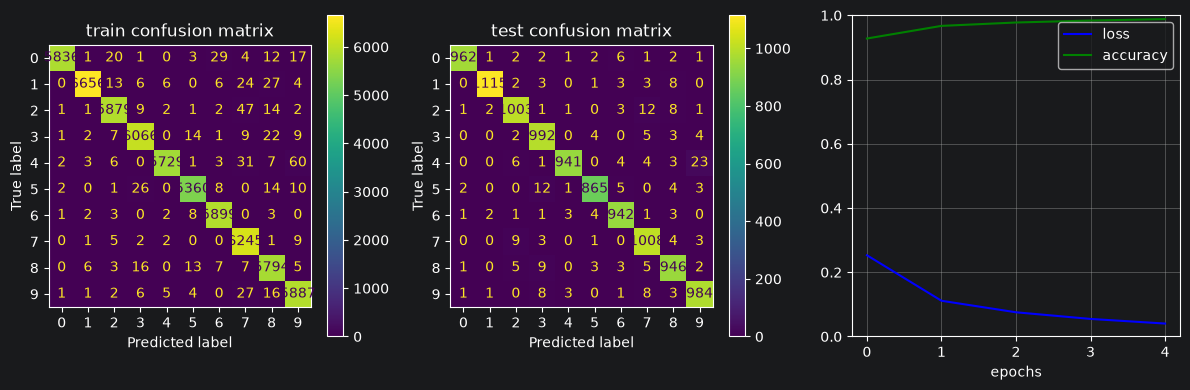

In [11]:
met0, mod0, cm_tr0, cm_te0, pred_te0, h0 = entrenar_evaluar(
    opt="adam",
    lr=0.001,
    batch_size=32,
    epochs=5,
    x_tr=x_train,
    y_tr=y_train,
    x_te=x_test,
    y_te=y_test,
)

metricas = pd.concat([metricas, pd.DataFrame([met0])], ignore_index=True)
display(metricas)
resumen(cm_tr0, cm_te0, h0)

En solo 13-15 s la pérdida cae rápido y alcanzamos un 97.58 % de acierto en test, cometiendo únicamente 242 fallos. La diferencia con el conjunto de entrenamiento (98.92 %) es de apenas un 1.3 %, lo que confirma que con 5 épocas el modelo no se ha memorizado los datos y generaliza muy bien. Si miramos la matriz de confusión, podemos ver que la confusión más repetida es clasificar un 4 como si fuera un 9 (23 casos) o un 5 como un 3 (12 casos).

### Experimento 1

En este experimento cambiamos el optimizador a SGD estándar con un learning rate de 0.01, manteniendo el lote en 32 y las 5 épocas. El objetivo es comparar el comportamiento frente a Adam al eliminar las tasas de aprendizaje adaptativas. SGD no adapta el paso a cada neurona, multiplica el gradiente del lote actual por una tasa fija. Subimos el learning rate a 0.01 porque con el 0.001 de Adam este algoritmo apenas avanzaría o iria muy lento, y le costaría más alcanzar la precisión del primer modelo en solo 5 épocas.

Epoch 1/5


D:\Dev\Universidad\uma-26-27-1\.venv\Lib\site-packages\keras\src\layers\reshaping\flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.8419 - loss: 0.6319   
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9079 - loss: 0.3324  
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - accuracy: 0.9204 - loss: 0.2849
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9286 - loss: 0.2552
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9349 - loss: 0.2328
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 1s 697us/step
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 768us/step


,optimizador,learning_rate,batch_size,epochs,tiempo_entrenamiento(s),train_accuracy,test_accuracy,errores_train,errores_test,precision,recall,f1_score,auc_roc
0,adam,0.001,32,5,14.46,0.9892,0.9758,649/60000,242/10000,0.9759,0.9756,0.9757,0.9996
1,sgd,0.010,32,5,11.01,0.9382,0.9375,3708/60000,625/10000,0.9372,0.9366,0.9367,0.9963


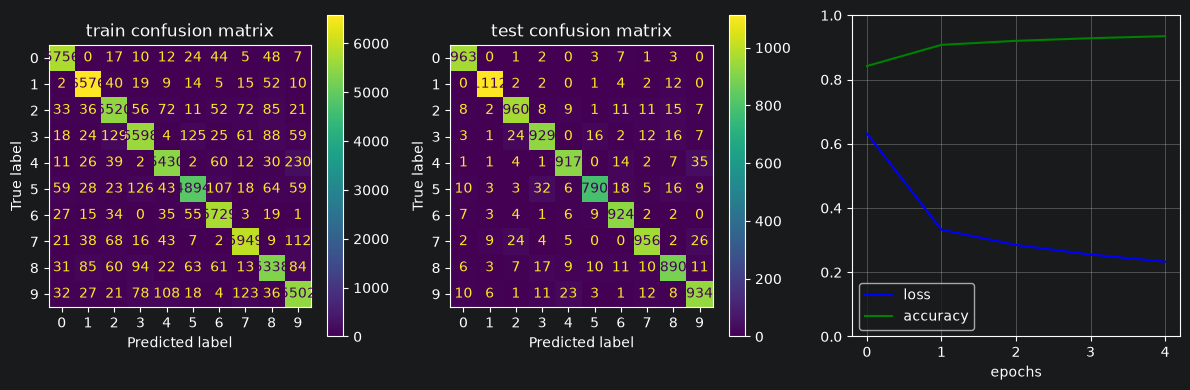

In [12]:
met1, mod1, cm_tr1, cm_te1, pred_te1, h1 = entrenar_evaluar(
    opt="sgd",
    lr=0.01,
    batch_size=32,
    epochs=5,
    x_tr=x_train,
    y_tr=y_train,
    x_te=x_test,
    y_te=y_test
)

metricas = pd.concat([metricas, pd.DataFrame([met1])], ignore_index=True)
display(metricas)
resumen(cm_tr1, cm_te1, h1)

SGD hace que el entrenamiento sea un poco más rápido (10-12 s frente a los 13-15 s de Adam) porque sus operaciones son mucho más simples y no calcula momentos adaptativos. La precisión en test cae bastante hasta el 93.75 %, pasando de 242 a 625 fallos. Mirando la gráfica de la derecha, la pérdida se queda atascada en torno a 0.23 y la línea sigue cayendo con pendiente, lo que demuestra que a SGD le faltan más épocas para llegar al nivel de convergencia que Adam logró en solo 5. En la matriz de confusión los fallos aumentan demasiado, destacando especialmente el 5 confundiéndose con el 3 (32 casos) y el 4 con el 9 (35 casos).

### Experimento 2

SGD se queda corto en 5 épocas, en este experimento probamos SGD con Momentum (fijado en 0.9), manteniendo el learning rate en 0.01, el lote en 32 y las 5 épocas. El objetivo es ver si añadiendo inercia resolvemos la lentitud de convergencia sin recurrir a algoritmos más complejos como Adam. El momentum acumula una fracción de los gradientes de los pasos anteriores, acelerando la convergencia y ayudando a escapar de mínimos locales pequeños gracias al impulso acumulado. Esperamos que la pérdida descienda con mucha más fuerza que con SGD básico y que la precisión en test se acerque más a los valores de Adam.

Epoch 1/5


D:\Dev\Universidad\uma-26-27-1\.venv\Lib\site-packages\keras\src\layers\reshaping\flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9131 - loss: 0.3020
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9585 - loss: 0.1450
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9700 - loss: 0.1038
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9769 - loss: 0.0816
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9813 - loss: 0.0672
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 1s 663us/step
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 760us/step


,optimizador,learning_rate,batch_size,epochs,tiempo_entrenamiento(s),train_accuracy,test_accuracy,errores_train,errores_test,precision,recall,f1_score,auc_roc
0,adam,0.001,32,5,14.46,0.9892,0.9758,649/60000,242/10000,0.9759,0.9756,0.9757,0.9996
1,sgd,0.010,32,5,11.01,0.9382,0.9375,3708/60000,625/10000,0.9372,0.9366,0.9367,0.9963
2,sgd_momentum,0.010,32,5,11.08,0.9835,0.9744,989/60000,256/10000,0.9744,0.9742,0.9742,0.9995


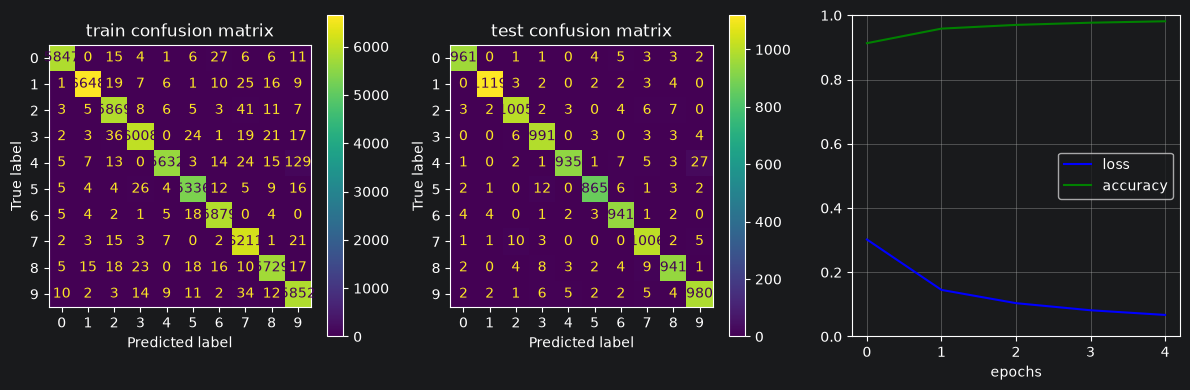

In [13]:
met2, mod2, cm_tr2, cm_te2, pred_te2, h2 = entrenar_evaluar(
    opt="sgd_momentum",
    lr=0.01,
    batch_size=32,
    epochs=5,
    x_tr=x_train,
    y_tr=y_train,
    x_te=x_test,
    y_te=y_test
)

metricas = pd.concat([metricas, pd.DataFrame([met2])], ignore_index=True)
display(metricas)
resumen(cm_tr2, cm_te2, h2)

Añadir momentum soluciona de golpe el problema de lentitud de SGD, la precisión en test sube del 93.75 % al 97.44 % y los fallos se reducen de 625 a solo 256, quedándose prácticamente a la par de Adam (242 fallos). Además, es el más rápido hasta ahora. Como se ve en la curva, acumular inercia de los pasos anteriores hace que la pérdida caiga con fuerza hasta 0.07 en lugar de estancarse. En las matrices de confusión disminuye los errores que teníamos en SGD simple, volviendo a concentrar casi todos los fallos en casos difíciles aislados, como confundir el 4 con el 9 (27 casos).

### Experimento 3

Para cerrar el bloque de optimizadores probamos RMSprop con un learning rate de 0.001, lote de 32 y 5 épocas. El objetivo es comparar otra técnica adaptativa frente a Adam. RMSprop divide el gradiente entre la raíz cuadrada de la media móvil de sus cuadrados recientes, modula el paso según si una dirección ha tenido gradientes grandes o pequeños, pero a diferencia de Adam no incluye un término de momentum en la actualización directa. Esperamos ver una convergencia muy rápida y limpia, similar a la del primer experimento, al adaptar la escala del gradiente en cada coordenada.

Epoch 1/5


D:\Dev\Universidad\uma-26-27-1\.venv\Lib\site-packages\keras\src\layers\reshaping\flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - accuracy: 0.9278 - loss: 0.2487
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9667 - loss: 0.1122
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9769 - loss: 0.0805
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - accuracy: 0.9821 - loss: 0.0636
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9855 - loss: 0.0526
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 1s 666us/step
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 786us/step


,optimizador,learning_rate,batch_size,epochs,tiempo_entrenamiento(s),train_accuracy,test_accuracy,errores_train,errores_test,precision,recall,f1_score,auc_roc
0,adam,0.001,32,5,14.46,0.9892,0.9758,649/60000,242/10000,0.9759,0.9756,0.9757,0.9996
1,sgd,0.010,32,5,11.01,0.9382,0.9375,3708/60000,625/10000,0.9372,0.9366,0.9367,0.9963
2,sgd_momentum,0.010,32,5,11.08,0.9835,0.9744,989/60000,256/10000,0.9744,0.9742,0.9742,0.9995
3,rmsprop,0.001,32,5,12.90,0.9857,0.9738,859/60000,262/10000,0.9738,0.9736,0.9736,0.9995


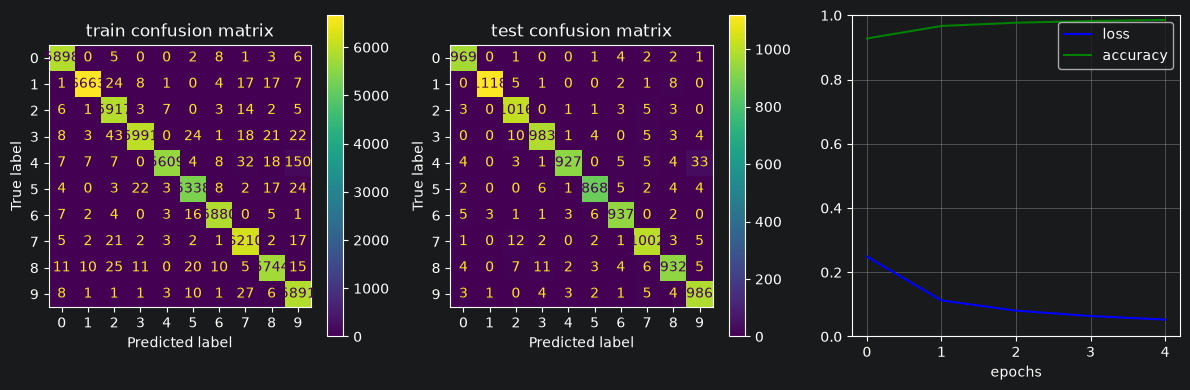

In [14]:
met3, mod3, cm_tr3, cm_te3, pred_te3, h3 = entrenar_evaluar(
    opt="rmsprop",
    lr=0.001,
    batch_size=32,
    epochs=5,
    x_tr=x_train,
    y_tr=y_train,
    x_te=x_test,
    y_te=y_test
)

metricas = pd.concat([metricas, pd.DataFrame([met3])], ignore_index=True)
display(metricas)
resumen(cm_tr3, cm_te3, h3)

RMSprop se queda muy cerca de Adam, logra un 97.38 % de acierto en test con 262 fallos en 11-13 s. Al adaptar la tasa de aprendizaje dividiendo por la media cuadrática de los gradientes, la pérdida desciende con fluidez y sin oscilaciones bruscas. Se queda apenas una décima por debajo de Adam (242 fallos) porque no incorpora el término de inercia que sí tiene este último para acelerar en zonas favorables, pero supera a SGD estándar. En la matriz de confusión volvemos a ver el patrón típico de errores, como la confusión entre el 4 y el 9 (33 casos).

Con esto queda cerrado el Bloque 1 - Optimizadores. Ahora entramos en el Bloque 2 - Tamaño de Lote (Batch Size). Mantendremos Adam con learning rate de 0.001 y 5 épocas, pero aumentaremos el tamaño de lote a 128 en el Experimento 4 para estudiar cómo afecta agrupar más imágenes por actualización.

## Bloque 2 - Tamaño de Lote (Batch Size)
### Experimento 4
Subimos el batch size a 128 (frente al valor base de 32), manteniendo Adam, learning rate de 0.001 y 5 épocas. El objetivo es analizar el impacto del tamaño de muestra en el cálculo del gradiente y en la velocidad de cómputo. Al cuadruplicar el lote, el modelo pasa de realizar 1.875 actualizaciones por época a solo 469; internamente, cada paso se calcula con una estimación del gradiente mucho más precisa y menos ruidosa, lo que estabiliza el descenso pero reduce el número total de correcciones en 5 épocas. Además, lotes más grandes permiten a la CPU paralelizar mejor las operaciones matriciales, por lo que esperamos una reducción notable en el tiempo de entrenamiento a costa de una posible y ligera pérdida de precisión.

Epoch 1/5


D:\Dev\Universidad\uma-26-27-1\.venv\Lib\site-packages\keras\src\layers\reshaping\flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


469/469 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9038 - loss: 0.3478    
Epoch 2/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9553 - loss: 0.1576  
Epoch 3/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9678 - loss: 0.1129  
Epoch 4/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9753 - loss: 0.0874 
Epoch 5/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9802 - loss: 0.0706  
469/469 ━━━━━━━━━━━━━━━━━━━━ 0s 985us/step
79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 998us/step


,optimizador,learning_rate,batch_size,epochs,tiempo_entrenamiento(s),train_accuracy,test_accuracy,errores_train,errores_test,precision,recall,f1_score,auc_roc
0,adam,0.001,32,5,14.46,0.9892,0.9758,649/60000,242/10000,0.9759,0.9756,0.9757,0.9996
1,sgd,0.010,32,5,11.01,0.9382,0.9375,3708/60000,625/10000,0.9372,0.9366,0.9367,0.9963
2,sgd_momentum,0.010,32,5,11.08,0.9835,0.9744,989/60000,256/10000,0.9744,0.9742,0.9742,0.9995
3,rmsprop,0.001,32,5,12.90,0.9857,0.9738,859/60000,262/10000,0.9738,0.9736,0.9736,0.9995
4,adam,0.001,128,5,5.22,0.9836,0.9752,986/60000,248/10000,0.9751,0.9751,0.9751,0.9994


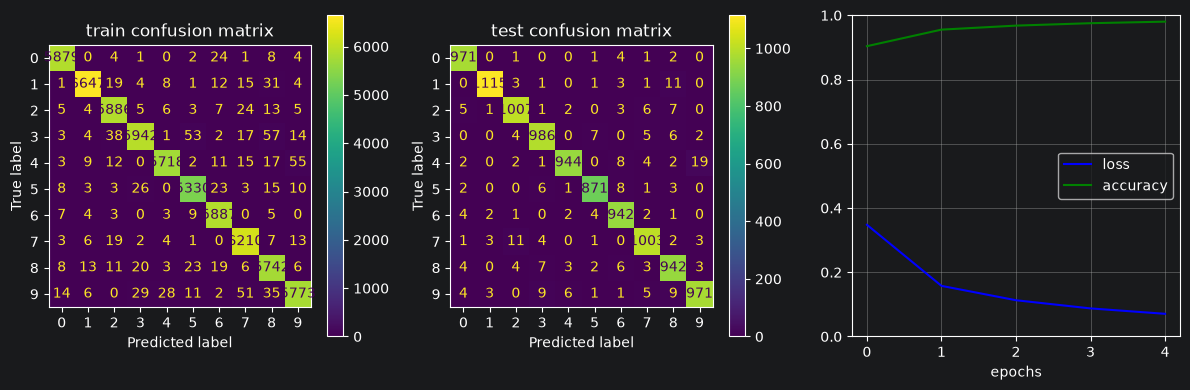

In [15]:
met4, mod4, cm_tr4, cm_te4, pred_te4, h4 = entrenar_evaluar(
    opt="adam",
    lr=0.001,
    batch_size=128,
    epochs=5,
    x_tr=x_train,
    y_tr=y_train,
    x_te=x_test,
    y_te=y_test
)

metricas = pd.concat([metricas, pd.DataFrame([met4])], ignore_index=True)
display(metricas)
resumen(cm_tr4, cm_te4, h4)

Subir el lote a 128 demuestra una mejora en eficiencia, el tiempo de entrenamiento baja a 4-6 s (tres veces más rápido) gracias a que la CPU procesa bloques de datos más grandes en paralelo. La precisión papenas cambia, logrando un 97.52 % en test con 248 fallos (apenas 6 errores más que la base de batch 32). Aunque el modelo solo hizo 469 actualizaciones por época, los momentos de Adam compensaron de sobra la menor frecuencia de pasos. En la matriz de confusión la estructura se mantiene limpia y los errores siguen concentrados en los mismos casos difíciles, como el 4 confundiéndose con el 9 (19 casos).

### Experimento 5

Llevamos el parámetro al extremo subiendo el batch size a 512, manteniendo Adam, una tasa de 0.001 y 5 épocas. El objetivo es comprobar los límites del paralelismo frente a la capacidad de aprendizaje del modelo. Al procesar lotes tan grandes, la red solo realizará 117 actualizaciones de pesos por época. Es muy probable que la pérdida no termine de bajar del todo y la precisión empiece a degradarse de forma más notable.

Epoch 1/5


D:\Dev\Universidad\uma-26-27-1\.venv\Lib\site-packages\keras\src\layers\reshaping\flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


118/118 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8475 - loss: 0.5745   
Epoch 2/5
118/118 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9315 - loss: 0.2458 
Epoch 3/5
118/118 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9464 - loss: 0.1893 
Epoch 4/5
118/118 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9567 - loss: 0.1540 
Epoch 5/5
118/118 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9639 - loss: 0.1294 
118/118 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 


,optimizador,learning_rate,batch_size,epochs,tiempo_entrenamiento(s),train_accuracy,test_accuracy,errores_train,errores_test,precision,recall,f1_score,auc_roc
0,adam,0.001,32,5,14.46,0.9892,0.9758,649/60000,242/10000,0.9759,0.9756,0.9757,0.9996
1,sgd,0.010,32,5,11.01,0.9382,0.9375,3708/60000,625/10000,0.9372,0.9366,0.9367,0.9963
2,sgd_momentum,0.010,32,5,11.08,0.9835,0.9744,989/60000,256/10000,0.9744,0.9742,0.9742,0.9995
3,rmsprop,0.001,32,5,12.90,0.9857,0.9738,859/60000,262/10000,0.9738,0.9736,0.9736,0.9995
4,adam,0.001,128,5,5.22,0.9836,0.9752,986/60000,248/10000,0.9751,0.9751,0.9751,0.9994
5,adam,0.001,512,5,2.26,0.9692,0.9632,1847/60000,368/10000,0.9630,0.9629,0.9629,0.9988


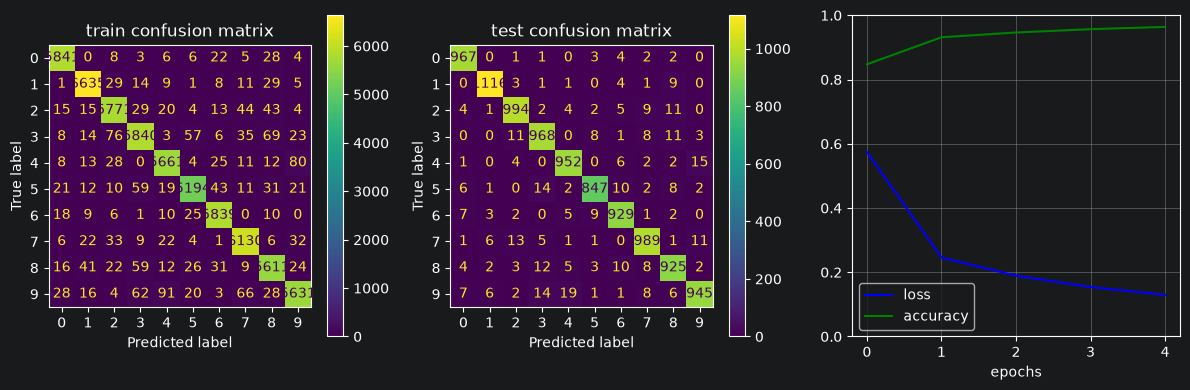

In [16]:
met5, mod5, cm_tr5, cm_te5, pred_te5, h5 = entrenar_evaluar(
    opt="adam",
    lr=0.001,
    batch_size=512,
    epochs=5,
    x_tr=x_train,
    y_tr=y_train,
    x_te=x_test,
    y_te=y_test
)

metricas = pd.concat([metricas, pd.DataFrame([met5])], ignore_index=True)
display(metricas)
resumen(cm_tr5, cm_te5, h5)

El tiempo de entrenamiento vuelve a bajar hasta los 2-4 s (seis veces más rápido que con lote de 32). Sin embargo, la exactitud en test cae al 96.32 % y los fallos aumentan hasta 368 (120 errores más que con lote de 128). Al haber agrupado tantas imágenes por lote, la red solo realiza unas 117 actualizaciones de pesos por época (menos de 600 en total); como se observa en la curva de pérdida, la línea sigue bajando con pendiente en torno a 0.13 y no llega a estabilizarse porque 5 épocas son claramente insuficientes para converger con tan pocas correcciones.

Con esto cerramos el Bloque 2 - Tamaño de Lota (Batch Size). Pasamos al Bloque 3 - Tasa de Aprendizaje (Learning Rate). Fijamos el lote en 32 y las 5 épocas, pero en el Experimento 6 subimos el learning rate de Adam a 0.01 (diez veces más alto que el original) para ver cómo afecta un avance mucho más agresivo.

## Bloque 3 - Tasa de Aprendizaje (Learning Rate)
### Experimento 6

Iniciamos el bloque de la tasa de aprendizaje aumentando el learning rate a 0.01 (frente al 0.001 base), manteniendo Adam, lote de 32 y 5 épocas. El objetivo es analizar si dar pasos más grandes acelera la convergencia o desestabiliza el aprendizaje. Esperamos una bajada muy agresiva en la primera época, pero con riesgo de perder precisión final si los saltos sobrepasan las soluciones más precisas.

Epoch 1/5


D:\Dev\Universidad\uma-26-27-1\.venv\Lib\site-packages\keras\src\layers\reshaping\flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9277 - loss: 0.2413
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9541 - loss: 0.1609
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9612 - loss: 0.1411
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9646 - loss: 0.1297
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - accuracy: 0.9666 - loss: 0.1248
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 1s 688us/step
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 786us/step


,optimizador,learning_rate,batch_size,epochs,tiempo_entrenamiento(s),train_accuracy,test_accuracy,errores_train,errores_test,precision,recall,f1_score,auc_roc
0,adam,0.001,32,5,14.46,0.9892,0.9758,649/60000,242/10000,0.9759,0.9756,0.9757,0.9996
1,sgd,0.010,32,5,11.01,0.9382,0.9375,3708/60000,625/10000,0.9372,0.9366,0.9367,0.9963
2,sgd_momentum,0.010,32,5,11.08,0.9835,0.9744,989/60000,256/10000,0.9744,0.9742,0.9742,0.9995
3,rmsprop,0.001,32,5,12.90,0.9857,0.9738,859/60000,262/10000,0.9738,0.9736,0.9736,0.9995
4,adam,0.001,128,5,5.22,0.9836,0.9752,986/60000,248/10000,0.9751,0.9751,0.9751,0.9994
5,adam,0.001,512,5,2.26,0.9692,0.9632,1847/60000,368/10000,0.9630,0.9629,0.9629,0.9988
6,adam,0.010,32,5,14.99,0.9686,0.9580,1884/60000,420/10000,0.9588,0.9569,0.9575,0.9983


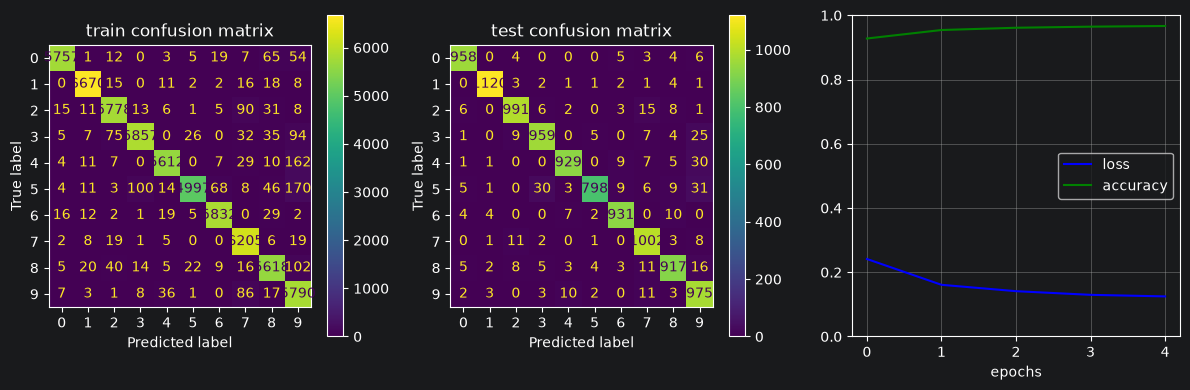

In [17]:
met6, mod6, cm_tr6, cm_te6, pred_te6, h6 = entrenar_evaluar(
    opt="adam",
    lr=0.01,
    batch_size=32,
    epochs=5,
    x_tr=x_train,
    y_tr=y_train,
    x_te=x_test,
    y_te=y_test
)

metricas = pd.concat([metricas, pd.DataFrame([met6])], ignore_index=True)
display(metricas)
resumen(cm_tr6, cm_te6, h6)

Subir la tasa de aprendizaje a 0.01 perjudica el rendimiento final. Aunque el tiempo de entrenamiento es el mismo que en la base, la exactitud en test cae al 95.80 % y los fallos se disparan hasta 420 (casi 180 errores más que con el 0.001 original). Mirando la curva de pérdida se ve cómo se frena enseguida en torno a 0.13 y deja de mejorar. Al combinar la inercia de Adam con un paso tan grande, sobrepasa los mínimos más precisos sin llegar a asentarse en ellos. En la matriz de confusión los fallos aumentan, especialmente con el 5 siendo confundido con el 3 y el 9 en más de 60 ocasiones.

Pasamos al Experimento 7 para cerrar el bloque de tasas de aprendizaje probando una tasa diez veces más baja, learning rate de 0.0001

### Experimento 7

Ahora reduciremos el learning rate a 0.0001 (diez veces más pequeño que la base), manteniendo Adam, lote de 32 y 5 épocas. El objetivo es comprobar el efecto de un avance excesivamente lento. Una tasa tan pequeña garantiza que las actualizaciones de los pesos sean muy suaves y nunca desestabilicen el modelo, pero hará un entrenamiento más lento. Esperamos que el entrenamiento sea muy estable y que la curva de pérdida baje de forma limpia, pero con el riesgo de que 5 épocas no sean suficientes para que el modelo alcance su punto óptimo, consiguiendo underfitting por falta de tiempo para converger.

Epoch 1/5


D:\Dev\Universidad\uma-26-27-1\.venv\Lib\site-packages\keras\src\layers\reshaping\flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8490 - loss: 0.6089
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - accuracy: 0.9220 - loss: 0.2853
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - accuracy: 0.9361 - loss: 0.2312
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - accuracy: 0.9453 - loss: 0.1970
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - accuracy: 0.9523 - loss: 0.1720
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 1s 708us/step
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 781us/step


,optimizador,learning_rate,batch_size,epochs,tiempo_entrenamiento(s),train_accuracy,test_accuracy,errores_train,errores_test,precision,recall,f1_score,auc_roc
0,adam,0.0010,32,5,14.46,0.9892,0.9758,649/60000,242/10000,0.9759,0.9756,0.9757,0.9996
1,sgd,0.0100,32,5,11.01,0.9382,0.9375,3708/60000,625/10000,0.9372,0.9366,0.9367,0.9963
2,sgd_momentum,0.0100,32,5,11.08,0.9835,0.9744,989/60000,256/10000,0.9744,0.9742,0.9742,0.9995
3,rmsprop,0.0010,32,5,12.90,0.9857,0.9738,859/60000,262/10000,0.9738,0.9736,0.9736,0.9995
4,adam,0.0010,128,5,5.22,0.9836,0.9752,986/60000,248/10000,0.9751,0.9751,0.9751,0.9994
5,adam,0.0010,512,5,2.26,0.9692,0.9632,1847/60000,368/10000,0.9630,0.9629,0.9629,0.9988
6,adam,0.0100,32,5,14.99,0.9686,0.9580,1884/60000,420/10000,0.9588,0.9569,0.9575,0.9983
7,adam,0.0001,32,5,14.61,0.9563,0.9519,2624/60000,481/10000,0.9516,0.9514,0.9515,0.9980


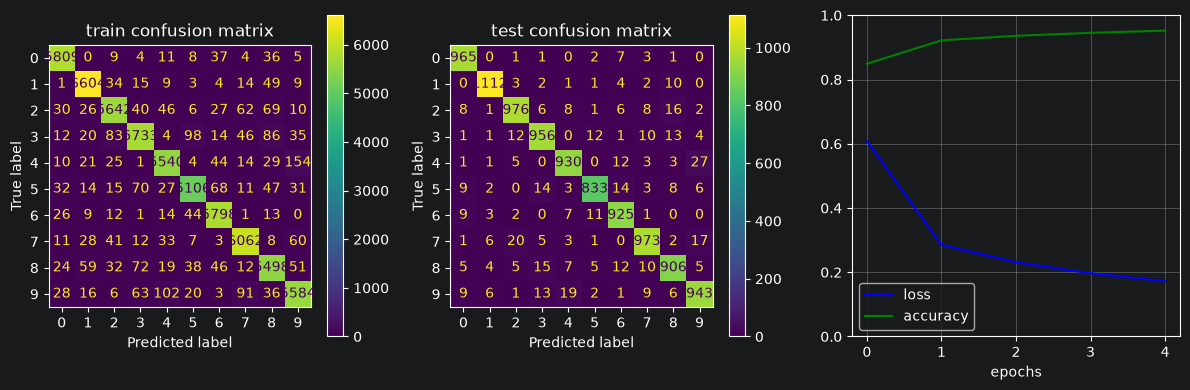

In [18]:
met7, mod7, cm_tr7, cm_te7, pred_te7, h7 = entrenar_evaluar(
    opt="adam",
    lr=0.0001,
    batch_size=32,
    epochs=5,
    x_tr=x_train,
    y_tr=y_train,
    x_te=x_test,
    y_te=y_test
)

metricas = pd.concat([metricas, pd.DataFrame([met7])], ignore_index=True)
display(metricas)
resumen(cm_tr7, cm_te7, h7)

Reducir tanto la tasa de aprendizaje obtenemos underfittinh. En los mismos 13-15 s, la precisión en test baja al 95.19 % y los fallos suben hasta 481 (el doble de errores que en el modelo base de Adam). Al ver la gráfica se aprecia claramente que la pérdida sigue cayendo con pendiente pronunciada hasta 0.17 y la curva no ha llegado a aplanarse. Con pasos tan pequeños el modelo iba por buen camino, pero 5 épocas son pocas para que termine de aprender. En la matriz de confusión los fallos se dispersan por muchas clases al no haber terminado de ajustar los detalles finos, destacando 27 confusiones del 4 con el 9 y 20 confusiones del 7 con el 2.

Cerramos el Bloque 3 - Tasa de Aprendizaje (Learning Rate), donde 0.001 ha demostrado ser con diferencia el valor óptimo frente a 0.01 y 0.0001 y pasamos al último Bloque 4 - Épocas

Para estos dos últimos experimentos fijamos la mejor combinación de parámetros vista hasta ahora: Adam, con learning rate de 0.001 y un lote de 64 (rápido y estable). En el Experimento 8 subimos a 12 épocas para comprobar si darle más tiempo a la red le permite batir el récord de precisión sin sobreajustar.

## Bloque 4 - Épocas
### Experimento 8

Iniciamos el bloque sobre la duración del entrenamiento aumentando las épocas a 12 (frente a las 5 base), utilizando el optimizador Adam con learning rate de 0.001 y un batch size intermedio de 64. El objetivo es comprobar si darle más tiempo de aprendizaje al modelo le permite afinar la separación entre clases difíciles o si, por el contrario, empieza a aparecer overfitting. Esperamos ver un incremento en la precisión de test superando la barrera del 98 %, vigilando que la brecha respecto a la exactitud de entrenamiento no crezca demasiado.

Epoch 1/12


D:\Dev\Universidad\uma-26-27-1\.venv\Lib\site-packages\keras\src\layers\reshaping\flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


938/938 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9182 - loss: 0.2934
Epoch 2/12
938/938 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9622 - loss: 0.1301
Epoch 3/12
938/938 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9734 - loss: 0.0905
Epoch 4/12
938/938 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9800 - loss: 0.0687
Epoch 5/12
938/938 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9847 - loss: 0.0535
Epoch 6/12
938/938 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9887 - loss: 0.0422
Epoch 7/12
938/938 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9917 - loss: 0.0332
Epoch 8/12
938/938 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9940 - loss: 0.0258
Epoch 9/12
938/938 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9957 - loss: 0.0203
Epoch 10/12
938/938 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9969 - loss: 0.0157
Epoch 11/12
938/938 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9977 - loss: 0.0129
Epoch 12/12
938/938 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy

,optimizador,learning_rate,batch_size,epochs,tiempo_entrenamiento(s),train_accuracy,test_accuracy,errores_train,errores_test,precision,recall,f1_score,auc_roc
0,adam,0.0010,32,5,14.46,0.9892,0.9758,649/60000,242/10000,0.9759,0.9756,0.9757,0.9996
1,sgd,0.0100,32,5,11.01,0.9382,0.9375,3708/60000,625/10000,0.9372,0.9366,0.9367,0.9963
2,sgd_momentum,0.0100,32,5,11.08,0.9835,0.9744,989/60000,256/10000,0.9744,0.9742,0.9742,0.9995
3,rmsprop,0.0010,32,5,12.90,0.9857,0.9738,859/60000,262/10000,0.9738,0.9736,0.9736,0.9995
4,adam,0.0010,128,5,5.22,0.9836,0.9752,986/60000,248/10000,0.9751,0.9751,0.9751,0.9994
5,adam,0.0010,512,5,2.26,0.9692,0.9632,1847/60000,368/10000,0.9630,0.9629,0.9629,0.9988
6,adam,0.0100,32,5,14.99,0.9686,0.9580,1884/60000,420/10000,0.9588,0.9569,0.9575,0.9983
7,adam,0.0001,32,5,14.61,0.9563,0.9519,2624/60000,481/10000,0.9516,0.9514,0.9515,0.9980
8,adam,0.0010,64,12,20.02,0.9964,0.9773,216/60000,227/10000,0.9773,0.9772,0.9772,0.9995


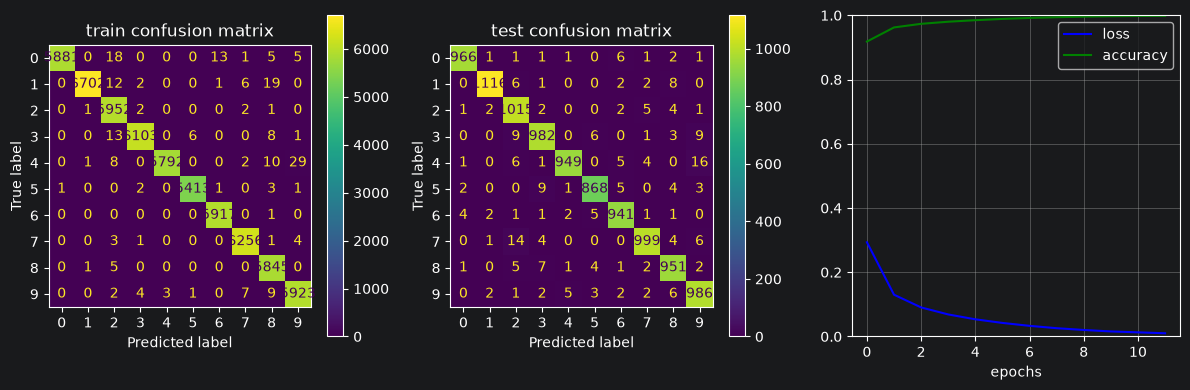

In [19]:
met8, mod8, cm_tr8, cm_te8, pred_te8, h8 = entrenar_evaluar(
    opt="adam",
    lr=0.001,
    batch_size=64,
    epochs=12,
    x_tr=x_train,
    y_tr=y_train,
    x_te=x_test,
    y_te=y_test
)

metricas = pd.concat([metricas, pd.DataFrame([met8])], ignore_index=True)
display(metricas)
resumen(cm_tr8, cm_te8, h8)

Con 12 épocas conseguimos el mejor resultado hasta el momento, la precisión en test sube al 97.73 % y reducimos los fallos a 227 (15 errores menos que en la línea base de 5 épocas). En 18-20 s de entrenamiento, la pérdida desciende casi hasta cero. En entrenamiento la exactitud la perfección con un 99.64 % (apenas 216 fallos en 60.000 imágenes). En la matriz de confusión, los fallos más notables se reducen sensiblemente: el 4 confundiéndose con el 9 baja a 16 casos y el 7 con el 2 se queda en 14.

Pasamos al Experimento 9 (el último). Para ver si podemos exprimir aún más el modelo o si caemos en sobreajuste, llevamos el entrenamiento a 20 épocas manteniendo Adam, learning rate de 0.001 y batch de 64.

### Experimento 9

Subimos las épocas hasta 20, manteniendo el optimizador Adam con learning rate de 0.001 y batch size de 64. Esperamos que el error en train sea prácticamente nulo, pero vigilaremos si la precisión en test se estanca o incluso empeora respecto al experimento de 12 épocas.

Epoch 1/20


D:\Dev\Universidad\uma-26-27-1\.venv\Lib\site-packages\keras\src\layers\reshaping\flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


938/938 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9182 - loss: 0.2934
Epoch 2/20
938/938 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9622 - loss: 0.1301
Epoch 3/20
938/938 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9734 - loss: 0.0905
Epoch 4/20
938/938 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9800 - loss: 0.0687
Epoch 5/20
938/938 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9847 - loss: 0.0535
Epoch 6/20
938/938 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9887 - loss: 0.0422
Epoch 7/20
938/938 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9917 - loss: 0.0332
Epoch 8/20
938/938 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9940 - loss: 0.0258
Epoch 9/20
938/938 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9957 - loss: 0.0203
Epoch 10/20
938/938 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9969 - loss: 0.0157
Epoch 11/20
938/938 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9977 - loss: 0.0129
Epoch 12/20
938/938 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy

,optimizador,learning_rate,batch_size,epochs,tiempo_entrenamiento(s),train_accuracy,test_accuracy,errores_train,errores_test,precision,recall,f1_score,auc_roc
0,adam,0.0010,32,5,14.46,0.9892,0.9758,649/60000,242/10000,0.9759,0.9756,0.9757,0.9996
1,sgd,0.0100,32,5,11.01,0.9382,0.9375,3708/60000,625/10000,0.9372,0.9366,0.9367,0.9963
2,sgd_momentum,0.0100,32,5,11.08,0.9835,0.9744,989/60000,256/10000,0.9744,0.9742,0.9742,0.9995
3,rmsprop,0.0010,32,5,12.90,0.9857,0.9738,859/60000,262/10000,0.9738,0.9736,0.9736,0.9995
4,adam,0.0010,128,5,5.22,0.9836,0.9752,986/60000,248/10000,0.9751,0.9751,0.9751,0.9994
5,adam,0.0010,512,5,2.26,0.9692,0.9632,1847/60000,368/10000,0.9630,0.9629,0.9629,0.9988
6,adam,0.0100,32,5,14.99,0.9686,0.9580,1884/60000,420/10000,0.9588,0.9569,0.9575,0.9983
7,adam,0.0001,32,5,14.61,0.9563,0.9519,2624/60000,481/10000,0.9516,0.9514,0.9515,0.9980
8,adam,0.0010,64,12,20.02,0.9964,0.9773,216/60000,227/10000,0.9773,0.9772,0.9772,0.9995
9,adam,0.0010,64,20,32.87,0.9971,0.9760,171/60000,240/10000,0.9758,0.9759,0.9758,0.9995


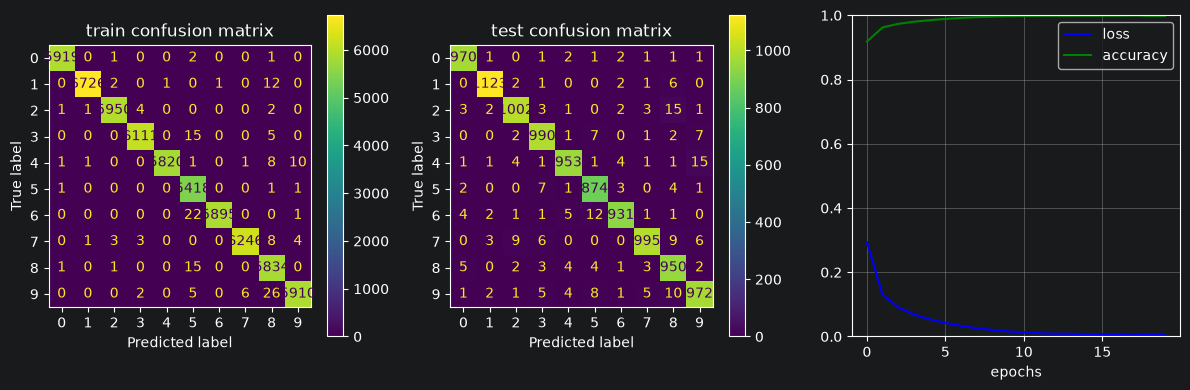

In [20]:
met9, mod9, cm_tr9, cm_te9, pred_te9, h9 = entrenar_evaluar(
    opt="adam",
    lr=0.001,
    batch_size=64,
    epochs=20,
    x_tr=x_train,
    y_tr=y_train,
    x_te=x_test,
    y_te=y_test
)

metricas = pd.concat([metricas, pd.DataFrame([met9])], ignore_index=True)
display(metricas)
resumen(cm_tr9, cm_te9, h9)

Subir a 20 épocas confirma el overfitting que anticipábamos: el tiempo de cómputo sube hasta los 28-32 s y la exactitud en test cae al 97.60 % con 240 fallos (13 errores más que con 12 épocas). En la matriz de test se ve que los fallos vuelven a dispersarse, destacando confusiones como clasificar el 4 como 9 (15 casos) o el 2 como 8 (15 casos). Con esto demostramos que 12 épocas era el punto óptimo y que seguir entrenando a partir de ahí empeora la capacidad de generalización.

## Resumen

In [21]:
df_resumen = pd.DataFrame(metricas).sort_values(by="test_accuracy", ascending=False)
display(df_resumen)

,optimizador,learning_rate,batch_size,epochs,tiempo_entrenamiento(s),train_accuracy,test_accuracy,errores_train,errores_test,precision,recall,f1_score,auc_roc
8,adam,0.0010,64,12,20.02,0.9964,0.9773,216/60000,227/10000,0.9773,0.9772,0.9772,0.9995
9,adam,0.0010,64,20,32.87,0.9971,0.9760,171/60000,240/10000,0.9758,0.9759,0.9758,0.9995
0,adam,0.0010,32,5,14.46,0.9892,0.9758,649/60000,242/10000,0.9759,0.9756,0.9757,0.9996
4,adam,0.0010,128,5,5.22,0.9836,0.9752,986/60000,248/10000,0.9751,0.9751,0.9751,0.9994
2,sgd_momentum,0.0100,32,5,11.08,0.9835,0.9744,989/60000,256/10000,0.9744,0.9742,0.9742,0.9995
3,rmsprop,0.0010,32,5,12.90,0.9857,0.9738,859/60000,262/10000,0.9738,0.9736,0.9736,0.9995
5,adam,0.0010,512,5,2.26,0.9692,0.9632,1847/60000,368/10000,0.9630,0.9629,0.9629,0.9988
6,adam,0.0100,32,5,14.99,0.9686,0.9580,1884/60000,420/10000,0.9588,0.9569,0.9575,0.9983
7,adam,0.0001,32,5,14.61,0.9563,0.9519,2624/60000,481/10000,0.9516,0.9514,0.9515,0.9980
1,sgd,0.0100,32,5,11.01,0.9382,0.9375,3708/60000,625/10000,0.9372,0.9366,0.9367,0.9963


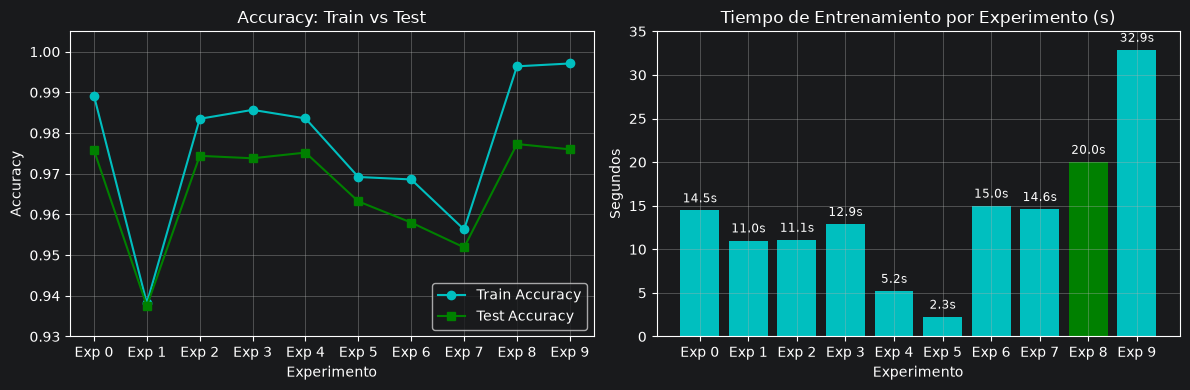

In [42]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

x = range(len(metricas))
nombres = [f"Exp {i}" for i in x]

axes[0].plot(x, metricas["train_accuracy"], marker='o', label="Train Accuracy", color="c")
axes[0].plot(x, metricas["test_accuracy"], marker='s', label="Test Accuracy", color="g")
axes[0].set_title("Accuracy: Train vs Test")
axes[0].set_xlabel("Experimento")
axes[0].set_ylabel("Accuracy")
axes[0].set_xticks(x)
axes[0].set_xticklabels(nombres)
axes[0].set_ylim(0.93, 1.005)
axes[0].grid()
axes[0].legend(loc="lower right")

colores_tiempo = ["c" if i != metricas["test_accuracy"].idxmax() else "g" for i in x]
bars = axes[1].bar(x, metricas["tiempo_entrenamiento(s)"], color=colores_tiempo)
axes[1].set_title("Tiempo de Entrenamiento por Experimento (s)")
axes[1].set_xlabel("Experimento")
axes[1].set_ylabel("Segundos")
axes[1].set_xticks(x)
axes[1].set_xticklabels(nombres)
axes[1].set_ylim(0, 35)
axes[1].grid()

for bar in bars:
    yval = bar.get_height()
    axes[1].text(bar.get_x() + bar.get_width()/2, yval + 0.6, f"{yval:.1f}s", ha='center', va='bottom', fontsize=8.5)

plt.tight_layout()
plt.show()

Tras evaluar las 10 configuraciones sobre el conjunto de datos, la configuración con mejor rendimiento global es la del Experimento 8:
- **Optimizador:** Adam
- **Tasa de aprendizaje ($\alpha$):** 0.001
- **Tamaño de lote (batch size):** 64
- **Épocas:** 12

1. Alcanza la el accuracy más alto en test (97.73 %) y el menor número de fallos 227 de 10.000 imágenes.
2. Aunque el Experimento 9 alcanzó un 99.71 % en entrenamiento, su rendimiento en test cayó a 97.60 % (240 errores). 12 épocas representa el punto óptimo antes de que la red empiece a memorizar ruido.
3. El uso de un batch size de 64 combinado con 12 épocas requirió únicamente 20 s

In [23]:
mod8.save("mejor_modelo_8.keras")